# MNIST with $k$-NN Prototypes
This introduction notebook keeps the code compact while showing a clean, modern workflow: load MNIST from the chapter-local `data/` folder, train a small $k$-nearest-neighbor classifier, and visualize both its overall behavior and one prototype-based explanation.

All displayed figures are saved into `out/` using the shared `xai_book.plotting` helpers.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

ROOT = Path.cwd()
while not (ROOT / 'xai_book').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUT_DIR = Path('out')
OUT_DIR.mkdir(parents=True, exist_ok=True)

def out_path(filename: str) -> Path:
    return OUT_DIR / filename

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

from xai_book.datasets import load_mnist_dataset
from xai_book.plotting import (
    BLUE,
    ORANGE,
    CHAPTER_GRAY,
    BACKGROUND,
    apply_notebook_style,
    display_and_save_figure,
    white_to_color_cmap,
)

DIGIT_CMAP = white_to_color_cmap(BLUE, name='mnist_blue')
HIGHLIGHT_CMAP = white_to_color_cmap(ORANGE, name='mnist_orange')


## Load a compact MNIST split and fit a simple model
The notebook uses a stratified subset so the example stays fast to rerun, but still produces a strong classifier and a meaningful nearest-neighbor explanation figure.


In [2]:
X_train, X_test, y_train, y_test, train_images, test_images, class_names = load_mnist_dataset(
    train_size=6000,
    test_size=1500,
    random_state=7,
)

k_neighbors = 7
knn = KNeighborsClassifier(n_neighbors=k_neighbors, weights='distance')
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
y_proba = knn.predict_proba(X_test)
accuracy = accuracy_score(y_test, y_pred)

summary = pd.DataFrame(
    {
        'Metric': ['Training images', 'Test images', '$k$', 'Accuracy'],
        'Value': [len(X_train), len(X_test), k_neighbors, f'{accuracy:.3f}'],
    }
)
summary


,Metric,Value
0,Training images,6000
1,Test images,1500
2,$k$,7
3,Accuracy,0.935


## Polished figures
The three figures below use the shared book palette and seaborn-backed notebook style. Titles use mathtext where it helps readability, but the notebook does not depend on an external LaTeX installation.


In [3]:
def make_class_prototype_grid(images: np.ndarray, labels: np.ndarray):
    apply_notebook_style(figsize=(11.2, 5.0), grid_axis='y')
    mean_images = np.stack([images[labels == digit].mean(axis=0) for digit in range(10)])

    fig, axes = plt.subplots(2, 5, figsize=(11.2, 5.0))
    fig.suptitle('Average MNIST prototypes by class', y=1.02, color=CHAPTER_GRAY)

    for digit, axis in enumerate(axes.flat):
        axis.imshow(mean_images[digit], cmap=DIGIT_CMAP, vmin=0.0, vmax=1.0)
        axis.set_title(fr'Digit ${digit}$', color=CHAPTER_GRAY, pad=8)
        axis.set_xticks([])
        axis.set_yticks([])
        axis.grid(False)
        spine_color = BLUE if digit < 5 else ORANGE
        for spine in axis.spines.values():
            spine.set_visible(True)
            spine.set_color(spine_color)
            spine.set_linewidth(1.4)

    return fig


def make_performance_overview(y_true: np.ndarray, y_pred: np.ndarray, score: float):
    apply_notebook_style(figsize=(12.2, 4.8), grid_axis='y')
    fig, (bar_ax, heatmap_ax) = plt.subplots(
        1,
        2,
        figsize=(12.2, 4.8),
        gridspec_kw={'width_ratios': [1.0, 1.25]},
    )

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(10))
    recalls = cm.diagonal() / cm.sum(axis=1)
    recall_frame = pd.DataFrame({'digit': np.arange(10), 'recall': recalls})
    weakest_digit = int(recall_frame.loc[recall_frame['recall'].idxmin(), 'digit'])
    recall_palette = {
        digit: ORANGE if digit == weakest_digit else BLUE
        for digit in recall_frame['digit']
    }

    sns.barplot(
        data=recall_frame,
        x='digit',
        y='recall',
        hue='digit',
        palette=recall_palette,
        dodge=False,
        ax=bar_ax,
    )
    if bar_ax.get_legend() is not None:
        bar_ax.get_legend().remove()
    bar_ax.axhline(score, linestyle='--', linewidth=1.5, color=CHAPTER_GRAY)
    bar_ax.text(
        0.02,
        0.96,
        rf'overall accuracy $= {score:.3f}$',
        transform=bar_ax.transAxes,
        ha='left',
        va='top',
        color=CHAPTER_GRAY,
        fontsize=11,
    )
    bar_ax.set_ylim(0.84, 1.01)
    bar_ax.set_xlabel('Digit')
    bar_ax.set_ylabel('Recall')
    bar_ax.set_title(r'Per-class recall for $k$-NN')
    sns.despine(ax=bar_ax)

    sns.heatmap(
        cm,
        cmap=DIGIT_CMAP,
        cbar=False,
        square=True,
        linewidths=0.6,
        linecolor=BACKGROUND,
        annot=True,
        fmt='d',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=heatmap_ax,
    )
    heatmap_ax.set_xlabel('Predicted digit')
    heatmap_ax.set_ylabel('True digit')
    heatmap_ax.set_title(r'Confusion matrix on the held-out split')

    fig.suptitle(r'$k$-NN performance on a compact MNIST split', y=1.03, color=CHAPTER_GRAY)
    return fig


def select_explanation_index(y_true: np.ndarray, y_pred: np.ndarray, y_proba: np.ndarray) -> int:
    confidence = y_proba.max(axis=1)
    candidate_mask = (y_true == y_pred) & (confidence > 0.55) & (confidence < 0.9)
    candidates = np.flatnonzero(candidate_mask)
    if len(candidates):
        target = 0.72
        return int(candidates[np.argmin(np.abs(confidence[candidates] - target))])

    correct = np.flatnonzero(y_true == y_pred)
    return int(correct[np.argmin(confidence[correct])])


def make_prototype_explanation(sample_index: int, n_neighbors: int = 7):
    apply_notebook_style(figsize=(13.2, 6.5), grid_axis='y')
    fig = plt.figure(figsize=(12.8, 6.4))
    grid = fig.add_gridspec(2, 5, width_ratios=[1.45, 1.0, 1.0, 1.0, 1.0], wspace=0.28, hspace=0.48)

    predicted_digit = int(y_pred[sample_index])
    true_digit = int(y_test[sample_index])
    confidence = float(y_proba[sample_index, predicted_digit])

    distances, neighbor_ids = knn.kneighbors(X_test[[sample_index]], n_neighbors=n_neighbors, return_distance=True)
    distances = distances[0]
    neighbor_ids = neighbor_ids[0]
    neighbor_labels = y_train[neighbor_ids]
    weights = 1.0 / (distances + 1e-6)
    weights = weights / weights.sum()

    vote_share = pd.DataFrame({'digit': np.arange(10), 'vote_share': np.zeros(10)})
    for label, weight in zip(neighbor_labels, weights):
        vote_share.loc[vote_share['digit'] == int(label), 'vote_share'] += weight
    vote_share = vote_share[vote_share['vote_share'] > 0].copy()

    query_ax = fig.add_subplot(grid[:, 0])
    query_ax.imshow(test_images[sample_index], cmap=HIGHLIGHT_CMAP, vmin=0.0, vmax=1.0)
    query_ax.set_title(
        f'Query\npred {predicted_digit} | true {true_digit}\nscore {confidence:.2f}',
        fontsize=12,
        color=CHAPTER_GRAY,
        pad=10,
    )
    query_ax.set_xticks([])
    query_ax.set_yticks([])
    query_ax.grid(False)
    for spine in query_ax.spines.values():
        spine.set_visible(True)
        spine.set_color(ORANGE)
        spine.set_linewidth(1.8)

    inset = inset_axes(query_ax, width='92%', height='24%', loc='lower center', borderpad=1.0)
    vote_palette = {
        int(digit): BLUE if int(digit) == predicted_digit else ORANGE
        for digit in vote_share['digit']
    }
    sns.barplot(
        data=vote_share,
        x='digit',
        y='vote_share',
        hue='digit',
        palette=vote_palette,
        dodge=False,
        ax=inset,
    )
    if inset.get_legend() is not None:
        inset.get_legend().remove()
    inset.set_title('Votes', fontsize=10, color=CHAPTER_GRAY, pad=4)
    inset.set_xlabel('')
    inset.set_ylabel('')
    inset.tick_params(axis='both', labelsize=9)
    inset.set_yticks([])
    inset.set_ylim(0, max(0.35, vote_share['vote_share'].max() + 0.05))
    sns.despine(ax=inset)

    for rank in range(n_neighbors):
        row = rank // 4
        col = 1 + (rank % 4)
        axis = fig.add_subplot(grid[row, col])
        label = int(neighbor_labels[rank])
        is_support = label == predicted_digit
        axis.imshow(
            train_images[neighbor_ids[rank]],
            cmap=DIGIT_CMAP if is_support else HIGHLIGHT_CMAP,
            vmin=0.0,
            vmax=1.0,
        )
        axis.set_title(
            f'#{rank + 1} | {label}\n{weights[rank]:.2f}',
            fontsize=10,
            color=CHAPTER_GRAY,
            pad=10,
        )
        axis.set_xticks([])
        axis.set_yticks([])
        axis.grid(False)
        border_color = BLUE if is_support else ORANGE
        for spine in axis.spines.values():
            spine.set_visible(True)
            spine.set_color(border_color)
            spine.set_linewidth(1.6)

    fig.suptitle('MNIST k-NN prototypes', y=0.98, color=CHAPTER_GRAY)
    fig.subplots_adjust(top=0.84, bottom=0.08)

    prototype_table = pd.DataFrame(
        {
            'rank': np.arange(1, n_neighbors + 1),
            'neighbor_digit': neighbor_labels.astype(int),
            'vote_weight': np.round(weights, 3),
            'distance': np.round(distances, 3),
        }
    )
    return fig, prototype_table


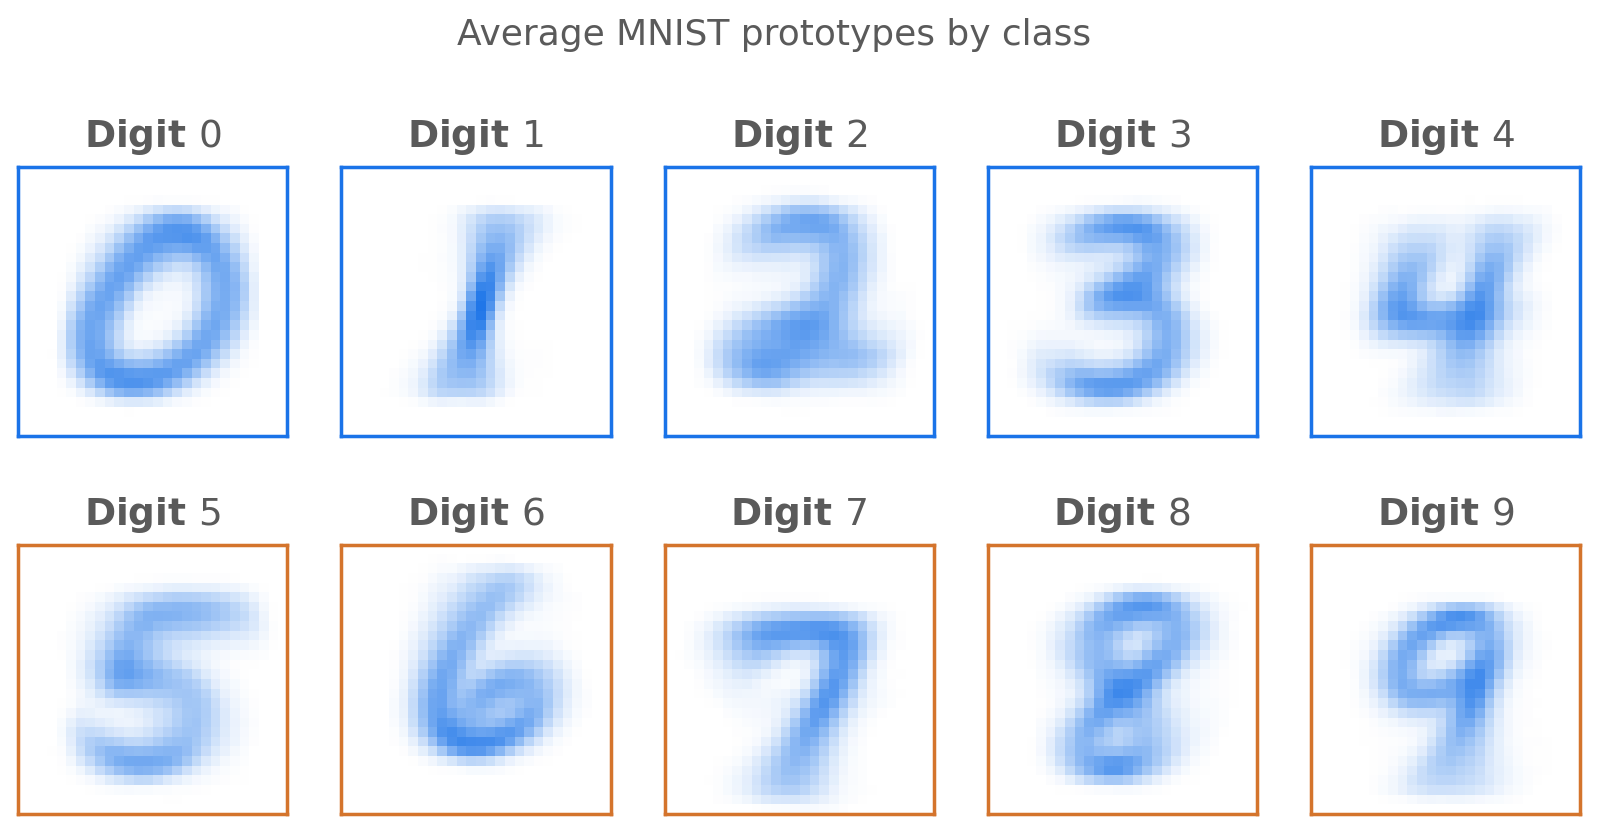

Saved: out/mnist_class_prototypes.pdf


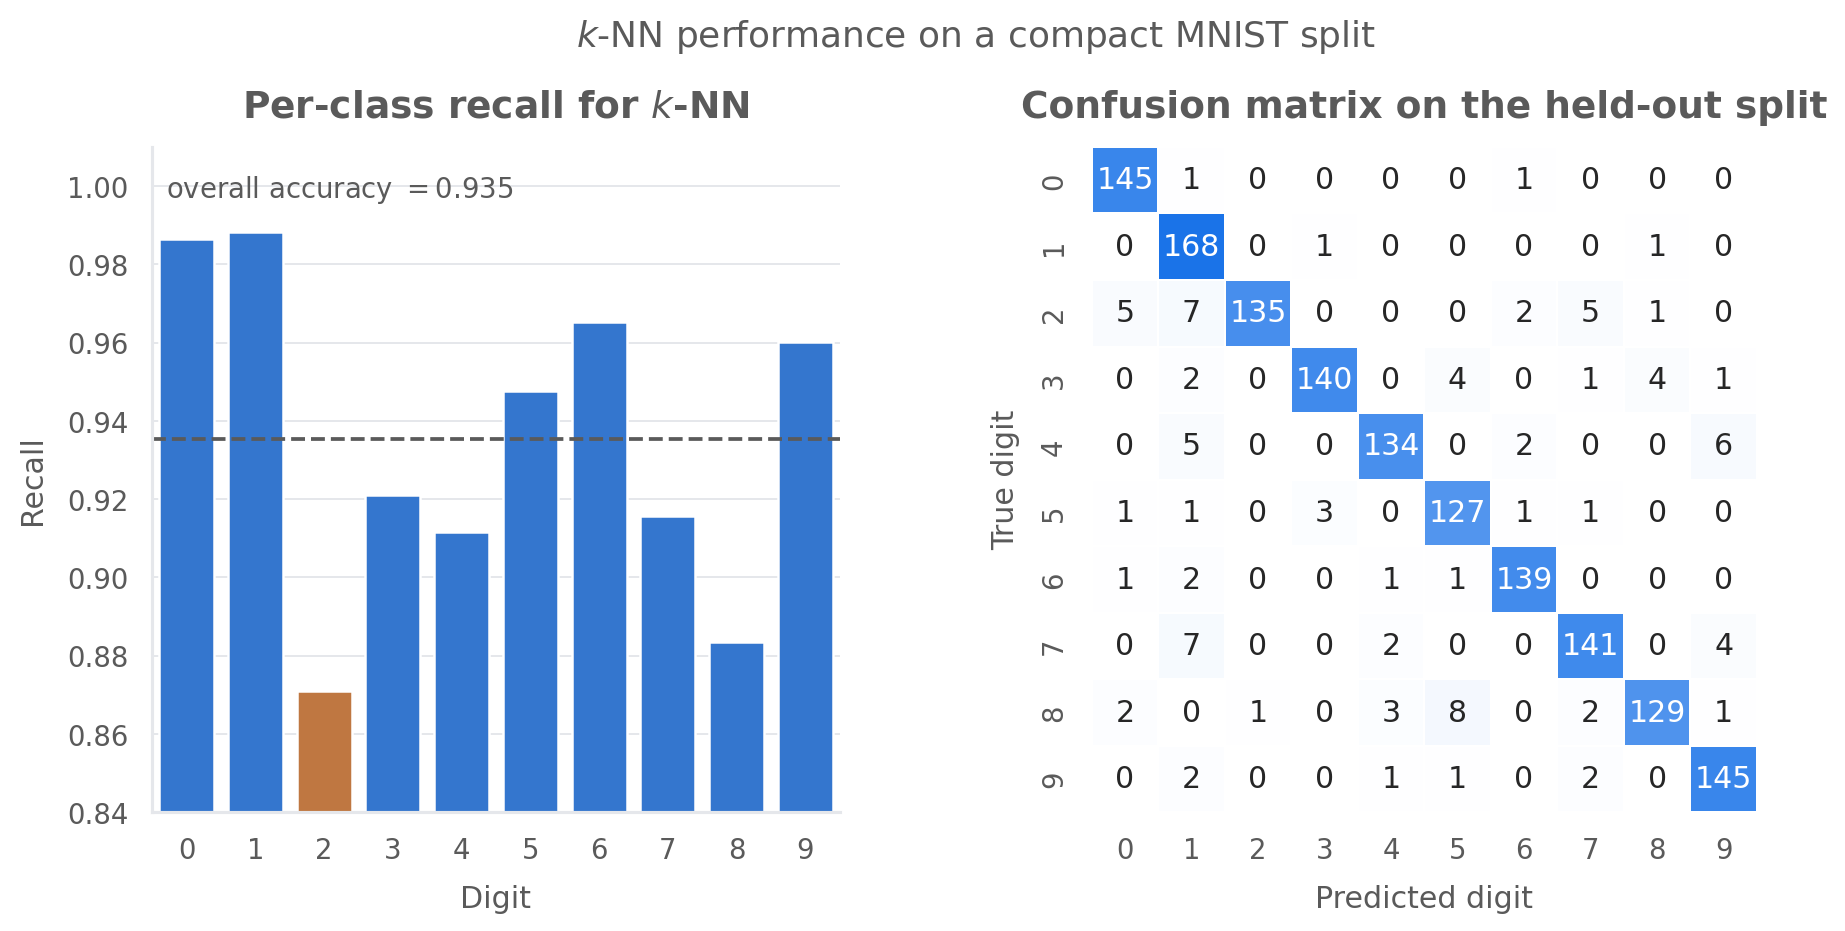

Saved: out/mnist_knn_performance.pdf


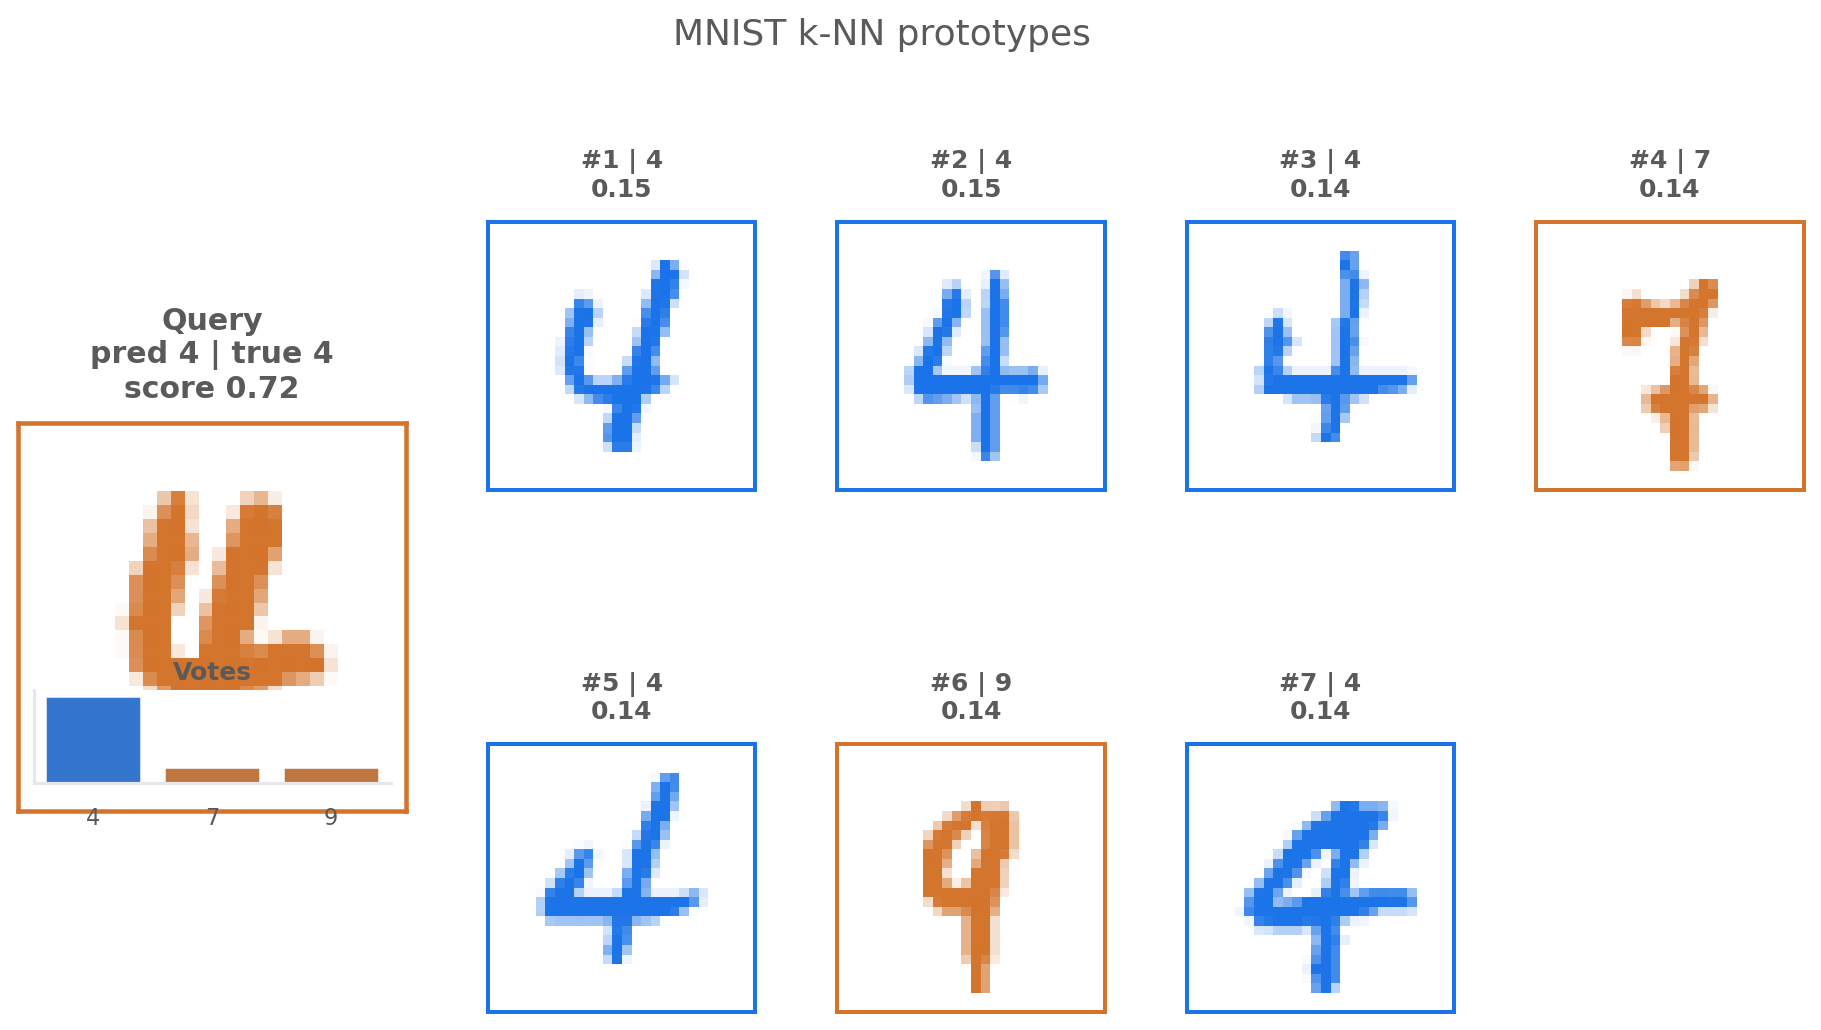

Saved: out/mnist_knn_prototype_explanation.pdf


,rank,neighbor_digit,vote_weight,distance
0,1,4,0.150,6.883
1,2,4,0.149,6.935
2,3,4,0.142,7.261
3,4,7,0.140,7.353
4,5,4,0.140,7.377
5,6,9,0.140,7.392
6,7,4,0.139,7.397


In [4]:
prototype_grid_path = display_and_save_figure(
    make_class_prototype_grid(train_images, y_train),
    out_path('mnist_class_prototypes.pdf'),
)
print('Saved:', prototype_grid_path)

performance_path = display_and_save_figure(
    make_performance_overview(y_test, y_pred, accuracy),
    out_path('mnist_knn_performance.pdf'),
)
print('Saved:', performance_path)

explanation_index = select_explanation_index(y_test, y_pred, y_proba)
prototype_fig, prototype_table = make_prototype_explanation(explanation_index, n_neighbors=k_neighbors)
prototype_path = display_and_save_figure(
    prototype_fig,
    out_path('mnist_knn_prototype_explanation.pdf'),
    tight_layout=False,
)
print('Saved:', prototype_path)

prototype_table


## Takeaway
A nearest-neighbor model is simple, but the explanation is still visual and concrete: the prediction is supported by a small set of prototype digits from the training set, and the competing neighbors show where the ambiguity comes from.
